In [5]:
# Example: Viewing default hyperparameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Create models with default hyperparameters
rf = RandomForestClassifier()
svm = SVC()
lr = LogisticRegression()

print("Random Forest Default Hyperparameters:")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  max_depth: {rf.max_depth}")
print(f"  min_samples_split: {rf.min_samples_split}")
print(f"  max_features: {rf.max_features}")

print("\nSVM Default Hyperparameters:")
print(f"  C: {svm.C}")
print(f"  kernel: {svm.kernel}")
print(f"  gamma: {svm.gamma}")

print("\nLogistic Regression Default Hyperparameters:")
print(f"  C: {lr.C}")
print(f"  penalty: {lr.penalty}")
print(f"  solver: {lr.solver}")

Random Forest Default Hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  max_features: sqrt

SVM Default Hyperparameters:
  C: 1.0
  kernel: rbf
  gamma: scale

Logistic Regression Default Hyperparameters:
  C: 1.0
  penalty: l2
  solver: lbfgs


In [7]:
# Example: Viewing default hyperparameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Create models with default hyperparameters
rf = RandomForestClassifier()
svm = SVC()
lr = LogisticRegression()

print("Random Forest Default Hyperparameters:")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  max_depth: {rf.max_depth}")
print(f"  min_samples_split: {rf.min_samples_split}")
print(f"  max_features: {rf.max_features}")

print("\nSVM Default Hyperparameters:")
print(f"  C: {svm.C}")
print(f"  kernel: {svm.kernel}")
print(f"  gamma: {svm.gamma}")

print("\nLogistic Regression Default Hyperparameters:")
print(f"  C: {lr.C}")
print(f"  penalty: {lr.penalty}")
print(f"  solver: {lr.solver}")

Random Forest Default Hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  max_features: sqrt

SVM Default Hyperparameters:
  C: 1.0
  kernel: rbf
  gamma: scale

Logistic Regression Default Hyperparameters:
  C: 1.0
  penalty: l2
  solver: lbfgs


In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Load the Wine Quality dataset
# Dataset link: https://archive.ics.uci.edu/ml/datasets/Wine+Quality
# We'll use the red wine dataset

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
wine_df = pd.read_csv(url, sep=';')
wine_df.head()

# Create binary target
wine_df['good_quality'] = (wine_df['quality'] >= 7).astype(int)

# Drop original quality column
wine_df = wine_df.drop('quality', axis=1)

# Check distribution
wine_df['good_quality'].value_counts(normalize=True)

X = wine_df.drop('good_quality', axis=1)
y = wine_df['good_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training samples: 1279
Testing samples: 320


In [11]:
# Example: Viewing default hyperparameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Create models with default hyperparameters
rf = RandomForestClassifier()
svm = SVC()
lr = LogisticRegression()

print("Random Forest Default Hyperparameters:")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  max_depth: {rf.max_depth}")
print(f"  min_samples_split: {rf.min_samples_split}")
print(f"  max_features: {rf.max_features}")

print("\nSVM Default Hyperparameters:")
print(f"  C: {svm.C}")
print(f"  kernel: {svm.kernel}")
print(f"  gamma: {svm.gamma}")

print("\nLogistic Regression Default Hyperparameters:")
print(f"  C: {lr.C}")
print(f"  penalty: {lr.penalty}")
print(f"  solver: {lr.solver}")

Random Forest Default Hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  max_features: sqrt

SVM Default Hyperparameters:
  C: 1.0
  kernel: rbf
  gamma: scale

Logistic Regression Default Hyperparameters:
  C: 1.0
  penalty: l2
  solver: lbfgs


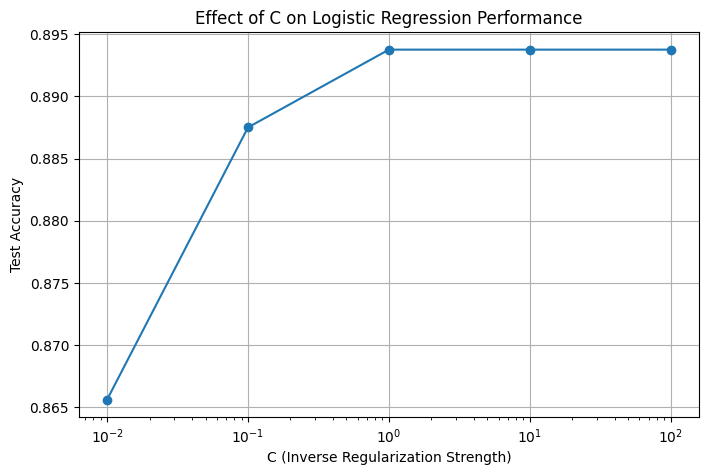

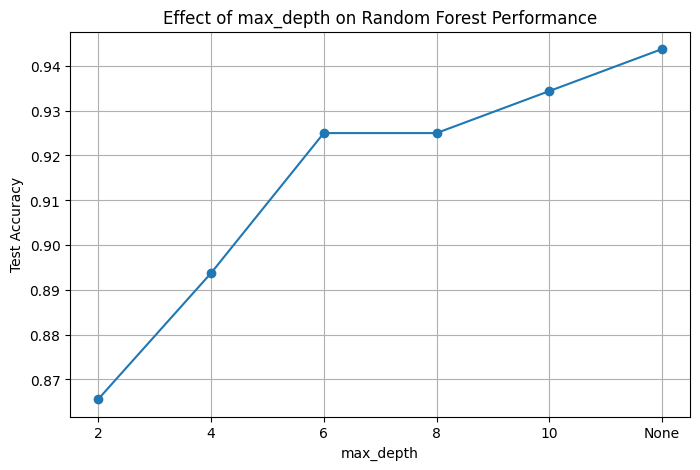

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression with different C values
C_values = [0.01, 0.1, 1, 10, 100]
logreg_scores = []
for c in C_values:
    model = LogisticRegression(C=c, max_iter=200, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    logreg_scores.append(acc)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(C_values, logreg_scores, marker='o')
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Test Accuracy')
plt.title('Effect of C on Logistic Regression Performance')
plt.grid(True)
plt.show()

# Random Forest with different max_depth values
depth_values = [2, 4, 6, 8, 10, None]
rf_scores = []
for depth in depth_values:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)  # no scaling needed for RF
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    rf_scores.append(acc)

# Plot results
plt.figure(figsize=(8,5))
labels = ['2', '4', '6', '8', '10', 'None']
plt.plot(labels, rf_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Test Accuracy')
plt.title('Effect of max_depth on Random Forest Performance')
plt.grid(True)
plt.show()

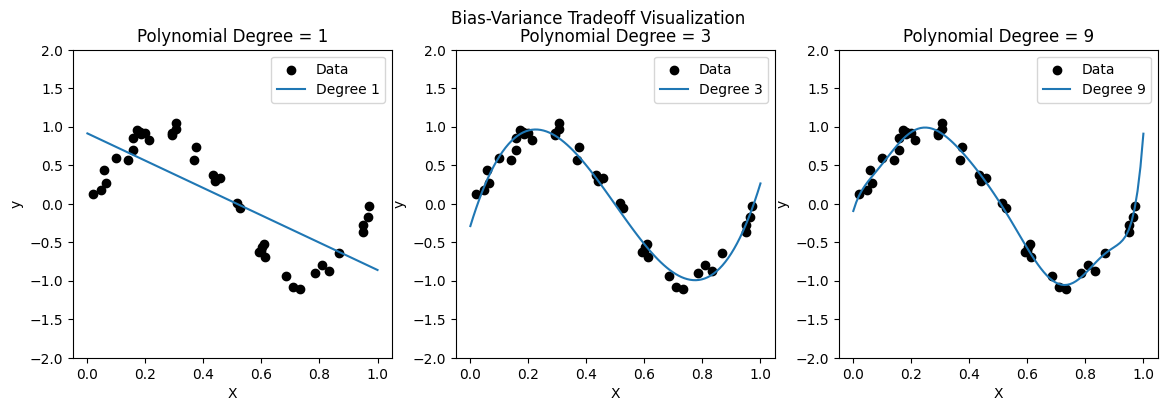

In [15]:
# Visualizing bias-variance tradeoff with polynomial regression on synthetic data
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

np.random.seed(42)
X_synthetic = np.sort(np.random.rand(40))
y_synthetic = np.sin(2 * np.pi * X_synthetic) + np.random.randn(40) * 0.1

X_plot = np.linspace(0, 1, 100)

degrees = [1, 3, 9]
plt.figure(figsize=(14, 4))
for i, degree in enumerate(degrees, 1):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_synthetic[:, np.newaxis], y_synthetic)
    y_plot = model.predict(X_plot[:, np.newaxis])

    plt.subplot(1, 3, i)
    plt.scatter(X_synthetic, y_synthetic, color='black', label='Data')
    plt.plot(X_plot, y_plot, label=f'Degree {degree}')
    plt.ylim(-2, 2)
    plt.legend()
    plt.title(f'Polynomial Degree = {degree}')
    plt.xlabel('X')
    plt.ylabel('y')

plt.suptitle('Bias-Variance Tradeoff Visualization')
plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation accuracies: {scores}")
print(f"Mean CV accuracy: {scores.mean():.4f}")

Cross-validation accuracies: [0.87890625 0.87109375 0.87890625 0.89453125 0.88627451]
Mean CV accuracy: 0.8819


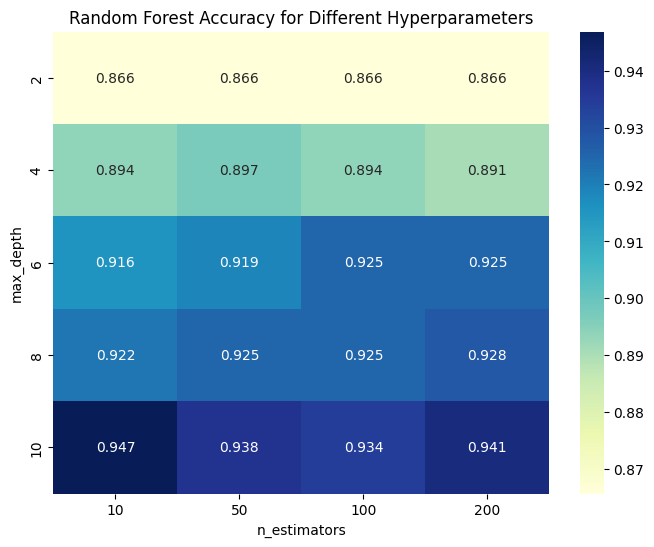

In [19]:
max_depth_values = [2, 4, 6, 8, 10]
n_estimators_values = [10, 50, 100, 200]

results = []
for depth in max_depth_values:
    for n_est in n_estimators_values:
        model = RandomForestClassifier(max_depth=depth, n_estimators=n_est, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        results.append({'max_depth': depth, 'n_estimators': n_est, 'accuracy': acc})

results_df = pd.DataFrame(results)
results_df

# Visualize results as heatmap
pivot_table = results_df.pivot(index='max_depth', columns='n_estimators', values='accuracy')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Random Forest Accuracy for Different Hyperparameters')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 6, 8],
    'n_estimators': [50, 100, 150],
    'max_features': ['auto', 'sqrt']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_preds = best_rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("Classification Report:")
print(classification_report(y_test, test_preds))

Best parameters found: {'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 50}
Best cross-validation accuracy: 0.8913
Test Accuracy: 0.925
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       277
           1       0.88      0.51      0.65        43

    accuracy                           0.93       320
   macro avg       0.90      0.75      0.80       320
weighted avg       0.92      0.93      0.92       320



In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# YOUR CODE BELOW

# Define parameter distributions
param_dist = {
    'max_depth': randint(2, 15),
    'n_estimators': randint(10, 200),
    'max_features': ['auto', 'sqrt', 'log2', None]
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit to training data
random_search.fit(X_train, y_train)

# Print best parameters and accuracy
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# Evaluate on test set
best_rf_random = random_search.best_estimator_
test_preds_random = best_rf_random.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, test_preds_random):.4f}")

Best parameters found: {'max_depth': 12, 'max_features': None, 'n_estimators': 198}
Best cross-validation accuracy: 0.8945
Test Accuracy: 0.9344


How did the results from Random Search compare to Grid Search?
Random Search achieved a high cross-validation accuracy of 0.8945 and a test accuracy of 0.9344, showing strong performance comparable to (or potentially better than) Grid Search, depending on the combinations explored.

Why might Random Search be more efficient than Grid Search?
Random Search is more efficient because it samples a wide range of hyperparameter values without testing every combination, allowing it to find strong results faster, especially when the search space is large.

In [25]:
# YOUR CODE BELOW

summary = pd.DataFrame({
    'Method': ['Manual Tuning', 'Grid Search', 'Random Search'],
    'Best Hyperparameters': [
        results_df.loc[results_df['accuracy'].idxmax(), ['max_depth', 'n_estimators']].to_dict(),
        grid_search.best_params_,
        random_search.best_params_
    ],
    'Test Accuracy': [
        results_df['accuracy'].max(),
        accuracy_score(y_test, best_rf.predict(X_test)),
        accuracy_score(y_test, best_rf_random.predict(X_test))
    ]
})

summary

,Method,Best Hyperparameters,Test Accuracy
0,Manual Tuning,"{'max_depth': 10.0, 'n_estimators': 10.0}",0.946875
1,Grid Search,"{'max_depth': 8, 'max_features': 'sqrt', 'n_es...",0.925000
2,Random Search,"{'max_depth': 12, 'max_features': None, 'n_est...",0.934375


Which method would you choose for a real-world project and why?
I would choose Random Search because it provides strong performance (0.9344) while being more efficient than Grid Search. Even though Manual Tuning performed best in this case (0.9469), it is not always reliable or scalable for larger problems.

What factors might influence your choice?
Time, computational resources, and dataset size are key factors. Grid Search can be expensive for large datasets, while Random Search is faster and more practical. Manual tuning depends heavily on experience and may not generalize well to complex models.

In [27]:
# Uncomment the next line to install AutoGluon if it's not installed
!pip install autogluon.tabular -q

from autogluon.tabular import TabularPredictor

# Prepare DataFrame for AutoGluon
train_data = X_train.copy()
train_data['good_quality'] = y_train.values

test_data = X_test.copy()
test_data['good_quality'] = y_test.values

# YOUR CODE BELOW

predictor = TabularPredictor(label='good_quality', eval_metric='accuracy').fit(
    train_data=train_data,
    time_limit=180,
    verbosity=2
)

# Show leaderboard
leaderboard = predictor.leaderboard(silent=True)
leaderboard

# Evaluate on test data
y_pred_automl = predictor.predict(test_data.drop(columns=['good_quality']))
acc_automl = accuracy_score(test_data['good_quality'], y_pred_automl)
print(f"AutoGluon Test Accuracy: {acc_automl:.4f}")

No path specified. Models will be saved in: "AutogluonModels/ag-20260425_010541"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.54 GB / 12.67 GB (83.2%)
Disk Space Avail:   86.94 GB / 107.72 GB (80.7%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.a

AutoGluon Test Accuracy: 0.9313


In [28]:
# Use this cell to write your summary and answers
from IPython.display import display

summary

,Method,Best Hyperparameters,Test Accuracy
0,Manual Tuning,"{'max_depth': 10.0, 'n_estimators': 10.0}",0.946875
1,Grid Search,"{'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 50}",0.925000
2,Random Search,"{'max_depth': 12, 'max_features': None, 'n_estimators': 198}",0.934375
